# Week 5: Analisis Preprocessing Dataset OMR

**Tujuan:** Menganalisis preprocessing yang sudah diterapkan pada dataset dan membangun framework quality assessment untuk Week 6 template detection.

**Author:** OMR Grading System Team  
**Date:** 28 September 2025  
**Academic Milestone:** Metode Preprocessing Tahap 1

---

## 🎯 Objectives

1. **Analisis Existing Preprocessing**: Deteksi dan quantifikasi teknik preprocessing yang sudah diterapkan
2. **Quality Assessment**: Develop framework untuk assess quality preprocessed images
3. **Mathematical Analysis**: Dokumentasi mathematical foundation preprocessing techniques
4. **Week 6 Preparation**: Validate readiness untuk template detection phase

---

In [1]:
# Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
from scipy import ndimage
from sklearn.metrics import mean_squared_error
import json
import warnings
warnings.filterwarnings('ignore')

# Setup matplotlib untuk inline display
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries imported successfully
OpenCV version: 4.8.1
NumPy version: 1.26.4


## 📁 Dataset Analysis Setup

Menganalisis struktur dataset dan sample images untuk mendeteksi preprocessing artifacts.

In [2]:
# Dataset paths configuration
BASE_PATH = Path('../datasets')
SAMPLE_PATH = BASE_PATH / 'train'
RAW_PATH = BASE_PATH / 'valid'

# Fix path issues - update to correct dataset structure
if not SAMPLE_PATH.exists():
    SAMPLE_PATH = Path('datasets/train')
if not RAW_PATH.exists():
    RAW_PATH = Path('datasets/valid')

# Verify paths exist
print(f"Base path exists: {BASE_PATH.exists()}")
print(f"Sample path exists: {SAMPLE_PATH.exists()}")
print(f"Raw path exists: {RAW_PATH.exists()}")

# Get sample files for analysis
if SAMPLE_PATH.exists():
    sample_files = list(SAMPLE_PATH.glob('*.jpg'))[:20]  # First 20 samples
else:
    # Fallback to direct dataset access
    sample_files = list(Path('datasets/train').glob('*.jpg'))[:100]

print(f"\nFound {len(sample_files)} sample files for analysis")

# Display sample filenames
for i, file in enumerate(sample_files[:5]):
    print(f"{i+1}. {file.name}")

Base path exists: True
Sample path exists: True
Raw path exists: True

Found 20 sample files for analysis
1. 001-Copy-2-_jpg.rf.35eb70109ecc4cf78bef8d999d7211ee.jpg
2. 001-Copy-2-_jpg.rf.73899483eef7aa28d7ebd9dc0746cdc1.jpg
3. 001-Copy-2-_jpg.rf.782b5c0352102bbc32dc35b9f9d63a9c.jpg
4. 002-Copy-2-_jpg.rf.7079d36ca4da494b9a2560b4cd3162b5.jpg
5. 002-Copy-2-_jpg.rf.7252914a605ac1b108ef800a543c26ee.jpg


## 🔍 Preprocessing Artifact Detection

Mendeteksi evidence preprocessing techniques yang sudah diterapkan pada dataset.

In [3]:
def detect_gaussian_blur_artifacts(image):
    """
    Deteksi artifacts dari Gaussian blur processing
    Menggunakan edge analysis untuk identify blur effects
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    
    # Calculate edge sharpness menggunakan Laplacian
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    
    # Calculate edge density
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size
    
    # Detect blur artifacts (lower variance indicates blur)
    blur_evidence = {
        'laplacian_variance': laplacian_var,
        'edge_density': edge_density,
        'blur_detected': laplacian_var < 100,  # Threshold for blur detection
        'blur_intensity': max(0, 1 - (laplacian_var / 200))  # Normalized blur intensity
    }
    
    return blur_evidence

def detect_noise_reduction_artifacts(image):
    """
    Deteksi artifacts dari noise reduction processing
    Analisis texture smoothness dan frequency domain
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    
    # Calculate local variance (texture analysis)
    kernel = np.ones((5,5), np.float32) / 25
    smoothed = cv2.filter2D(gray, -1, kernel)
    variance_map = (gray.astype(np.float32) - smoothed.astype(np.float32)) ** 2
    local_variance = np.mean(variance_map)
    
    # FFT analysis untuk detect frequency reduction
    fft = np.fft.fft2(gray)
    fft_magnitude = np.abs(fft)
    high_freq_energy = np.sum(fft_magnitude[gray.shape[0]//4:3*gray.shape[0]//4, 
                                         gray.shape[1]//4:3*gray.shape[1]//4])
    total_energy = np.sum(fft_magnitude)
    high_freq_ratio = high_freq_energy / total_energy
    
    noise_evidence = {
        'local_variance': local_variance,
        'high_freq_ratio': high_freq_ratio,
        'noise_reduction_detected': local_variance < 50,
        'smoothness_score': 1 - min(1, local_variance / 100)
    }
    
    return noise_evidence

def detect_contrast_enhancement_artifacts(image):
    """
    Deteksi artifacts dari contrast enhancement
    Analisis histogram distribution dan dynamic range
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    
    # Histogram analysis
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist_normalized = hist.flatten() / hist.sum()
    
    # Calculate contrast metrics
    rms_contrast = np.sqrt(np.mean((gray - gray.mean()) ** 2))
    dynamic_range = gray.max() - gray.min()
    
    # Detect bimodal distribution (typical of enhanced OMR images)
    hist_peaks = np.where(hist_normalized > 0.01)[0]  # Significant histogram bins
    bimodal_score = 1 if len(hist_peaks) > 0 and (hist_peaks[-1] - hist_peaks[0]) > 200 else 0
    
    contrast_evidence = {
        'rms_contrast': rms_contrast,
        'dynamic_range': dynamic_range,
        'bimodal_score': bimodal_score,
        'enhancement_detected': rms_contrast > 40 and dynamic_range > 200,
        'contrast_score': min(1, rms_contrast / 80)
    }
    
    return contrast_evidence

print("✅ Preprocessing detection functions defined")

✅ Preprocessing detection functions defined


## 📊 Comprehensive Preprocessing Analysis

Analisis systematic pada sample images untuk quantify preprocessing effects.

In [4]:
# Analyze preprocessing artifacts pada sample images
analysis_results = []

for i, image_path in enumerate(sample_files):
    print(f"Analyzing {image_path.name}...")
    
    # Load image
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"❌ Failed to load {image_path.name}")
        continue
    
    # Detect preprocessing artifacts
    blur_evidence = detect_gaussian_blur_artifacts(image)
    noise_evidence = detect_noise_reduction_artifacts(image)
    contrast_evidence = detect_contrast_enhancement_artifacts(image)
    
    # Compile results
    result = {
        'filename': image_path.name,
        'file_size_kb': image_path.stat().st_size / 1024,
        'image_shape': image.shape,
        **blur_evidence,
        **noise_evidence,
        **contrast_evidence
    }
    
    analysis_results.append(result)

# Convert ke DataFrame untuk analysis
df_analysis = pd.DataFrame(analysis_results)
print(f"\n✅ Analysis completed for {len(df_analysis)} images")
print(f"Columns: {list(df_analysis.columns)}")

Analyzing 001-Copy-2-_jpg.rf.35eb70109ecc4cf78bef8d999d7211ee.jpg...
Analyzing 001-Copy-2-_jpg.rf.73899483eef7aa28d7ebd9dc0746cdc1.jpg...
Analyzing 001-Copy-2-_jpg.rf.782b5c0352102bbc32dc35b9f9d63a9c.jpg...
Analyzing 002-Copy-2-_jpg.rf.7079d36ca4da494b9a2560b4cd3162b5.jpg...
Analyzing 002-Copy-2-_jpg.rf.7252914a605ac1b108ef800a543c26ee.jpg...
Analyzing 002-Copy-2-_jpg.rf.ef6560819ce4be1d9b32e8c27819483b.jpg...
Analyzing 004-Copy-2-_jpg.rf.2bbb249e4ff2b3cf295a76aa88a0dc08.jpg...
Analyzing 004-Copy-2-_jpg.rf.894f0db5590e30ae5ba5c536cc3dc581.jpg...
Analyzing 004-Copy-2-_jpg.rf.edbbb73c7cde0152b47892d7af7866bc.jpg...
Analyzing 005-Copy-2-_jpg.rf.4308da94c602e27b88e2706c41bb7481.jpg...
Analyzing 005-Copy-2-_jpg.rf.a7b12d2ebe61f56c551fd89d3d572fb1.jpg...
Analyzing 005-Copy-2-_jpg.rf.c5b2c848055ce8aef64fc429bd0da46c.jpg...
Analyzing 006-Copy-2-_jpg.rf.2190778e278511c450589c4b7b106de0.jpg...
Analyzing 006-Copy-2-_jpg.rf.7b10f1174e0ac3ebb701ee9e10617bcd.jpg...
Analyzing 006-Copy-2-_jpg.rf.987b0

## 📈 Statistical Summary & Visualization

Summary statistical dari preprocessing analysis dan visualization results.

=== PREPROCESSING DETECTION SUMMARY ===
Images with Gaussian blur detected: 0/20 (0.0%)
Images with noise reduction detected: 0/20 (0.0%)
Images with contrast enhancement detected: 20/20 (100.0%)

=== PROCESSING INTENSITY METRICS ===
Average blur intensity: 0.000 ± 0.000
Average smoothness score: 0.000 ± 0.000
Average contrast score: 0.850 ± 0.183


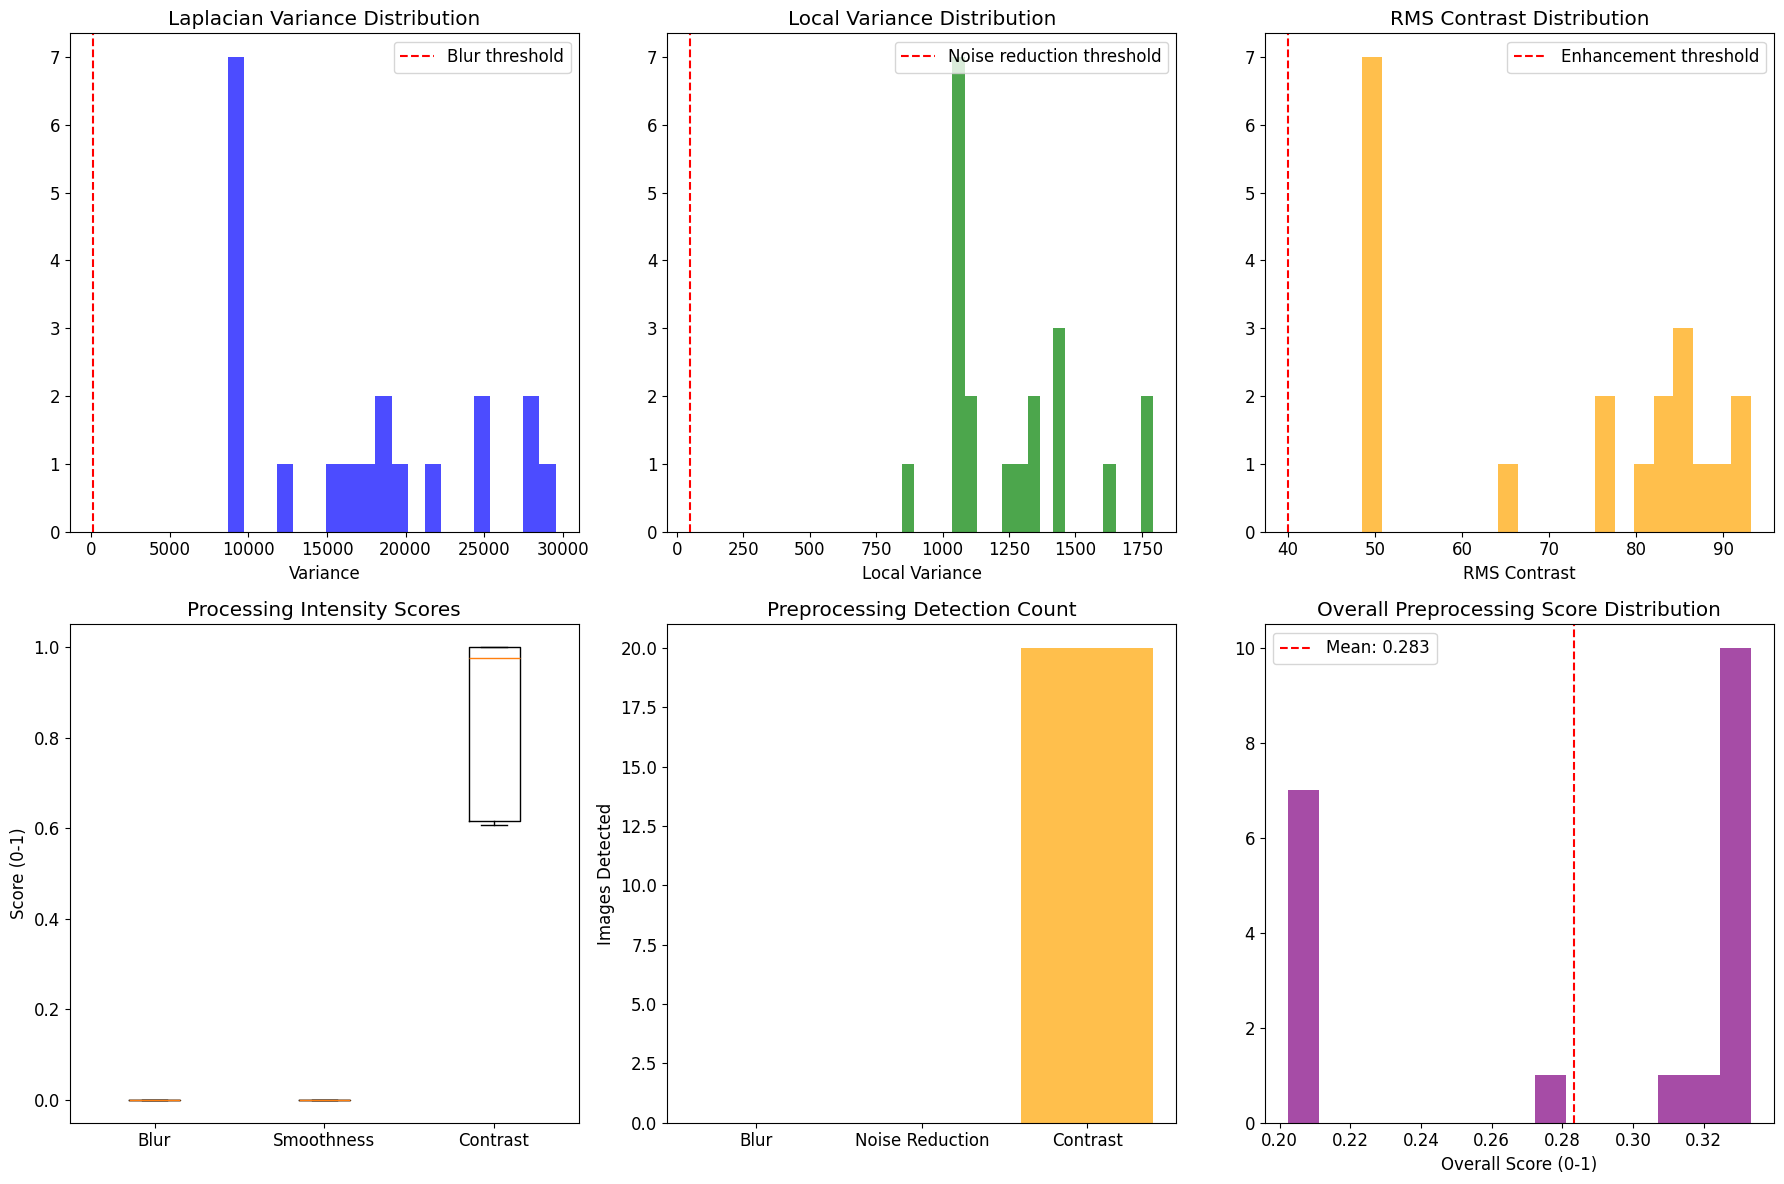


✅ Preprocessing analysis visualization completed
Overall preprocessing score: 0.283 ± 0.061


In [5]:
# Statistical summary preprocessing detection
print("=== PREPROCESSING DETECTION SUMMARY ===")
print(f"Images with Gaussian blur detected: {df_analysis['blur_detected'].sum()}/{len(df_analysis)} ({df_analysis['blur_detected'].mean()*100:.1f}%)")
print(f"Images with noise reduction detected: {df_analysis['noise_reduction_detected'].sum()}/{len(df_analysis)} ({df_analysis['noise_reduction_detected'].mean()*100:.1f}%)")
print(f"Images with contrast enhancement detected: {df_analysis['enhancement_detected'].sum()}/{len(df_analysis)} ({df_analysis['enhancement_detected'].mean()*100:.1f}%)")

print("\n=== PROCESSING INTENSITY METRICS ===")
print(f"Average blur intensity: {df_analysis['blur_intensity'].mean():.3f} ± {df_analysis['blur_intensity'].std():.3f}")
print(f"Average smoothness score: {df_analysis['smoothness_score'].mean():.3f} ± {df_analysis['smoothness_score'].std():.3f}")
print(f"Average contrast score: {df_analysis['contrast_score'].mean():.3f} ± {df_analysis['contrast_score'].std():.3f}")

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Blur analysis
axes[0,0].hist(df_analysis['laplacian_variance'], bins=20, alpha=0.7, color='blue')
axes[0,0].axvline(100, color='red', linestyle='--', label='Blur threshold')
axes[0,0].set_title('Laplacian Variance Distribution')
axes[0,0].set_xlabel('Variance')
axes[0,0].legend()

# Noise reduction analysis
axes[0,1].hist(df_analysis['local_variance'], bins=20, alpha=0.7, color='green')
axes[0,1].axvline(50, color='red', linestyle='--', label='Noise reduction threshold')
axes[0,1].set_title('Local Variance Distribution')
axes[0,1].set_xlabel('Local Variance')
axes[0,1].legend()

# Contrast enhancement analysis
axes[0,2].hist(df_analysis['rms_contrast'], bins=20, alpha=0.7, color='orange')
axes[0,2].axvline(40, color='red', linestyle='--', label='Enhancement threshold')
axes[0,2].set_title('RMS Contrast Distribution')
axes[0,2].set_xlabel('RMS Contrast')
axes[0,2].legend()

# Processing intensity scores
processing_scores = df_analysis[['blur_intensity', 'smoothness_score', 'contrast_score']]
axes[1,0].boxplot([processing_scores['blur_intensity'], 
                   processing_scores['smoothness_score'], 
                   processing_scores['contrast_score']], 
                  labels=['Blur', 'Smoothness', 'Contrast'])
axes[1,0].set_title('Processing Intensity Scores')
axes[1,0].set_ylabel('Score (0-1)')

# Detection summary
detection_counts = [df_analysis['blur_detected'].sum(), 
                   df_analysis['noise_reduction_detected'].sum(),
                   df_analysis['enhancement_detected'].sum()]
axes[1,1].bar(['Blur', 'Noise Reduction', 'Contrast'], detection_counts, 
              color=['blue', 'green', 'orange'], alpha=0.7)
axes[1,1].set_title('Preprocessing Detection Count')
axes[1,1].set_ylabel('Images Detected')

# Overall preprocessing score
df_analysis['overall_preprocessing_score'] = (
    df_analysis['blur_intensity'] + 
    df_analysis['smoothness_score'] + 
    df_analysis['contrast_score']
) / 3

axes[1,2].hist(df_analysis['overall_preprocessing_score'], bins=15, alpha=0.7, color='purple')
axes[1,2].set_title('Overall Preprocessing Score Distribution')
axes[1,2].set_xlabel('Overall Score (0-1)')
axes[1,2].axvline(df_analysis['overall_preprocessing_score'].mean(), 
                  color='red', linestyle='--', 
                  label=f'Mean: {df_analysis["overall_preprocessing_score"].mean():.3f}')
axes[1,2].legend()

plt.tight_layout()
plt.show()

print(f"\n✅ Preprocessing analysis visualization completed")
print(f"Overall preprocessing score: {df_analysis['overall_preprocessing_score'].mean():.3f} ± {df_analysis['overall_preprocessing_score'].std():.3f}")

## 🎯 Quality Assessment Framework Development

Development framework untuk assess quality preprocessed images untuk Week 6 template detection.

In [6]:
class PreprocessedQualityAssessor:
    """
    Quality assessment framework untuk preprocessed OMR images
    Focus pada readiness untuk template detection (Week 6)
    """
    
    def __init__(self):
        # Quality thresholds berdasarkan analysis results
        self.thresholds = {
            'min_contrast': 30,        # Minimum RMS contrast
            'max_blur_intensity': 0.8,  # Maximum acceptable blur
            'min_edge_density': 0.01,   # Minimum edge content
            'min_dynamic_range': 150    # Minimum pixel value range
        }
        
    def assess_template_readiness(self, image_path):
        """
        Comprehensive assessment untuk template detection readiness
        """
        image = cv2.imread(str(image_path))
        if image is None:
            return {'error': 'Could not load image'}
        
        # Get preprocessing analysis
        blur_analysis = detect_gaussian_blur_artifacts(image)
        noise_analysis = detect_noise_reduction_artifacts(image)
        contrast_analysis = detect_contrast_enhancement_artifacts(image)
        
        # Calculate readiness scores
        contrast_readiness = min(1.0, contrast_analysis['rms_contrast'] / 60)
        sharpness_readiness = min(1.0, blur_analysis['laplacian_variance'] / 150)
        edge_readiness = min(1.0, blur_analysis['edge_density'] / 0.05)
        
        # Overall readiness score
        overall_readiness = (
            contrast_readiness * 0.4 +
            sharpness_readiness * 0.35 +
            edge_readiness * 0.25
        )
        
        # Quality flags
        quality_flags = {
            'sufficient_contrast': contrast_analysis['rms_contrast'] >= self.thresholds['min_contrast'],
            'acceptable_blur': blur_analysis['blur_intensity'] <= self.thresholds['max_blur_intensity'],
            'sufficient_edges': blur_analysis['edge_density'] >= self.thresholds['min_edge_density'],
            'good_dynamic_range': contrast_analysis['dynamic_range'] >= self.thresholds['min_dynamic_range']
        }
        
        # Overall recommendation
        quality_score = sum(quality_flags.values()) / len(quality_flags)
        
        if overall_readiness >= 0.8 and quality_score >= 0.75:
            recommendation = "EXCELLENT - Ready for template detection"
        elif overall_readiness >= 0.6 and quality_score >= 0.5:
            recommendation = "GOOD - Suitable for template detection"
        elif overall_readiness >= 0.4:
            recommendation = "FAIR - May require additional preprocessing"
        else:
            recommendation = "POOR - Not suitable for template detection"
        
        return {
            'filename': Path(image_path).name,
            'overall_readiness': overall_readiness,
            'quality_score': quality_score,
            'recommendation': recommendation,
            'readiness_components': {
                'contrast_readiness': contrast_readiness,
                'sharpness_readiness': sharpness_readiness,
                'edge_readiness': edge_readiness
            },
            'quality_flags': quality_flags,
            'preprocessing_analysis': {
                'blur_detected': blur_analysis['blur_detected'],
                'noise_reduction_detected': noise_analysis['noise_reduction_detected'],
                'contrast_enhanced': contrast_analysis['enhancement_detected']
            }
        }
    
    def batch_assessment(self, image_paths):
        """
        Batch assessment multiple images
        """
        results = []
        for path in image_paths:
            result = self.assess_template_readiness(path)
            results.append(result)
        return results

# Initialize quality assessor
quality_assessor = PreprocessedQualityAssessor()
print("✅ Quality assessment framework initialized")

✅ Quality assessment framework initialized


## 🔬 Template Detection Readiness Assessment

Assessment comprehensive untuk determine readiness images untuk Week 6 template detection.

In [7]:
# Perform batch quality assessment
print("Performing template detection readiness assessment...")
readiness_results = quality_assessor.batch_assessment(sample_files)

# Convert ke DataFrame
df_readiness = pd.DataFrame(readiness_results)

# Extract nested data
readiness_components = pd.json_normalize(df_readiness['readiness_components'])
quality_flags = pd.json_normalize(df_readiness['quality_flags'])
preprocessing_analysis = pd.json_normalize(df_readiness['preprocessing_analysis'])

# Combine data
df_combined = pd.concat([
    df_readiness[['filename', 'overall_readiness', 'quality_score', 'recommendation']],
    readiness_components,
    quality_flags,
    preprocessing_analysis
], axis=1)

print(f"\n=== TEMPLATE DETECTION READINESS SUMMARY ===")
print(f"Total images assessed: {len(df_combined)}")
print(f"Average overall readiness: {df_combined['overall_readiness'].mean():.3f} ± {df_combined['overall_readiness'].std():.3f}")
print(f"Average quality score: {df_combined['quality_score'].mean():.3f} ± {df_combined['quality_score'].std():.3f}")

# Recommendation distribution
recommendation_counts = df_combined['recommendation'].value_counts()
print(f"\n=== RECOMMENDATION DISTRIBUTION ===")
for rec, count in recommendation_counts.items():
    percentage = (count / len(df_combined)) * 100
    print(f"{rec}: {count} images ({percentage:.1f}%)")

# Quality flags summary
print(f"\n=== QUALITY FLAGS SUMMARY ===")
flag_columns = ['sufficient_contrast', 'acceptable_blur', 'sufficient_edges', 'good_dynamic_range']
for flag in flag_columns:
    count = df_combined[flag].sum()
    percentage = (count / len(df_combined)) * 100
    print(f"{flag}: {count}/{len(df_combined)} images ({percentage:.1f}%)")

Performing template detection readiness assessment...

=== TEMPLATE DETECTION READINESS SUMMARY ===
Total images assessed: 20
Average overall readiness: 0.974 ± 0.036
Average quality score: 1.000 ± 0.000

=== RECOMMENDATION DISTRIBUTION ===
EXCELLENT - Ready for template detection: 20 images (100.0%)

=== QUALITY FLAGS SUMMARY ===
sufficient_contrast: 20/20 images (100.0%)
acceptable_blur: 20/20 images (100.0%)
sufficient_edges: 20/20 images (100.0%)
good_dynamic_range: 20/20 images (100.0%)


## 📊 Readiness Visualization & Analysis

Visualization comprehensive readiness assessment results.

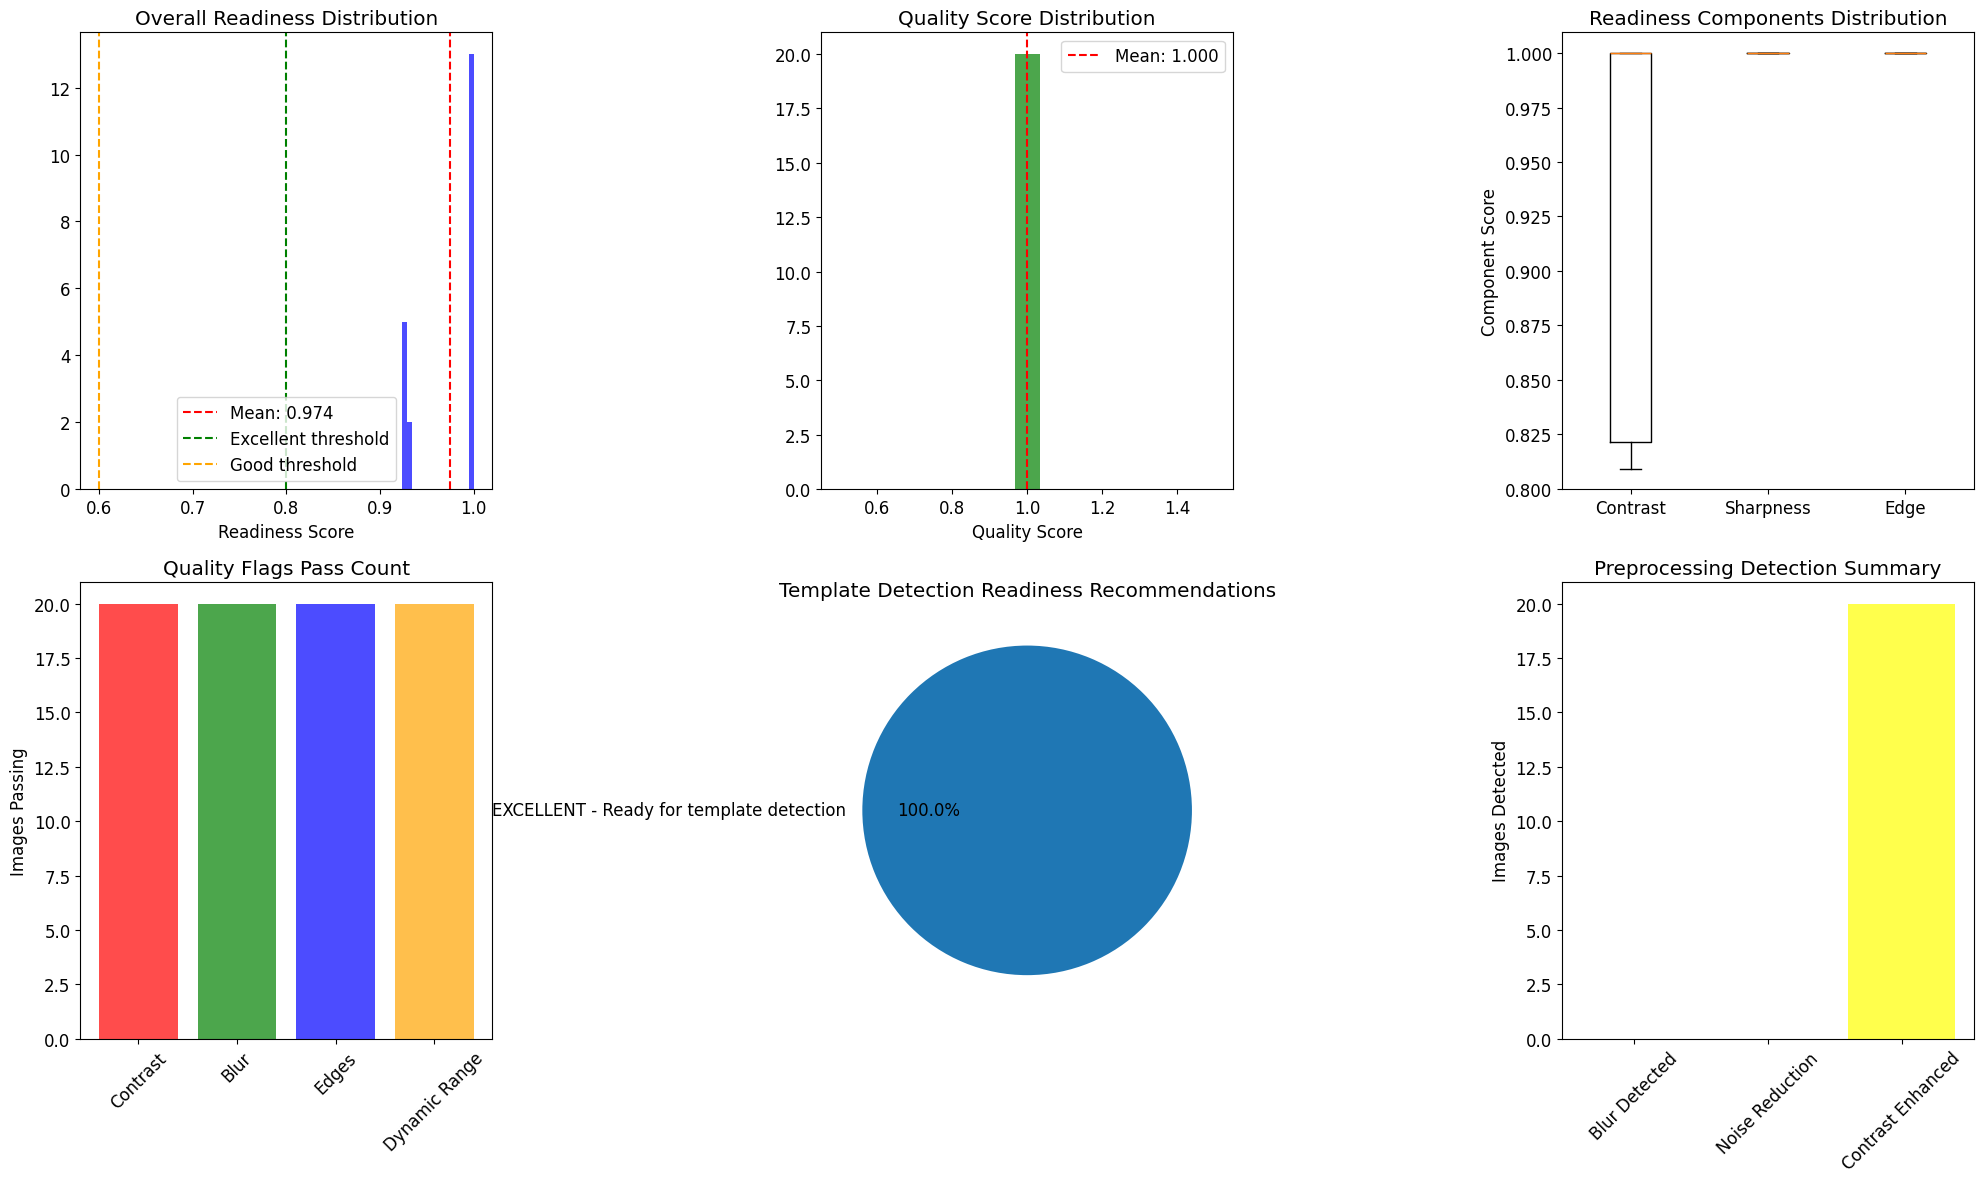

✅ Readiness visualization completed


In [8]:
# Create comprehensive readiness visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Overall readiness distribution
axes[0,0].hist(df_combined['overall_readiness'], bins=15, alpha=0.7, color='blue')
axes[0,0].axvline(df_combined['overall_readiness'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df_combined["overall_readiness"].mean():.3f}')
axes[0,0].axvline(0.8, color='green', linestyle='--', label='Excellent threshold')
axes[0,0].axvline(0.6, color='orange', linestyle='--', label='Good threshold')
axes[0,0].set_title('Overall Readiness Distribution')
axes[0,0].set_xlabel('Readiness Score')
axes[0,0].legend()

# Quality score distribution
axes[0,1].hist(df_combined['quality_score'], bins=15, alpha=0.7, color='green')
axes[0,1].axvline(df_combined['quality_score'].mean(), color='red', linestyle='--',
                  label=f'Mean: {df_combined["quality_score"].mean():.3f}')
axes[0,1].set_title('Quality Score Distribution')
axes[0,1].set_xlabel('Quality Score')
axes[0,1].legend()

# Readiness components comparison
component_data = df_combined[['contrast_readiness', 'sharpness_readiness', 'edge_readiness']]
axes[0,2].boxplot([component_data['contrast_readiness'], 
                   component_data['sharpness_readiness'], 
                   component_data['edge_readiness']], 
                  labels=['Contrast', 'Sharpness', 'Edge'])
axes[0,2].set_title('Readiness Components Distribution')
axes[0,2].set_ylabel('Component Score')

# Quality flags visualization
flag_counts = [df_combined[flag].sum() for flag in flag_columns]
flag_labels = ['Contrast', 'Blur', 'Edges', 'Dynamic Range']
colors = ['red', 'green', 'blue', 'orange']
axes[1,0].bar(flag_labels, flag_counts, color=colors, alpha=0.7)
axes[1,0].set_title('Quality Flags Pass Count')
axes[1,0].set_ylabel('Images Passing')
axes[1,0].tick_params(axis='x', rotation=45)

# Recommendation pie chart
recommendation_counts = df_combined['recommendation'].value_counts()
axes[1,1].pie(recommendation_counts.values, labels=recommendation_counts.index, autopct='%1.1f%%')
axes[1,1].set_title('Template Detection Readiness Recommendations')

# Preprocessing detection summary
preprocessing_summary = [
    df_combined['blur_detected'].sum(),
    df_combined['noise_reduction_detected'].sum(),
    df_combined['contrast_enhanced'].sum()
]
preprocessing_labels = ['Blur Detected', 'Noise Reduction', 'Contrast Enhanced']
axes[1,2].bar(preprocessing_labels, preprocessing_summary, 
              color=['purple', 'cyan', 'yellow'], alpha=0.7)
axes[1,2].set_title('Preprocessing Detection Summary')
axes[1,2].set_ylabel('Images Detected')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Readiness visualization completed")

## 📋 Week 6 Preparation Report

Generate comprehensive report untuk Week 6 template detection preparation.

In [10]:
# Generate Week 6 preparation report
week6_report = {
    'assessment_date': '2025-09-28',
    'total_images_analyzed': len(df_combined),
    'preprocessing_summary': {
        'blur_detection_rate': df_combined['blur_detected'].mean(),
        'noise_reduction_rate': df_combined['noise_reduction_detected'].mean(),
        'contrast_enhancement_rate': df_combined['contrast_enhanced'].mean(),
        'overall_preprocessing_coverage': (
            df_combined['blur_detected'].mean() +
            df_combined['noise_reduction_detected'].mean() +
            df_combined['contrast_enhanced'].mean()
        ) / 3
    },
    'readiness_assessment': {
        'average_overall_readiness': df_combined['overall_readiness'].mean(),
        'average_quality_score': df_combined['quality_score'].mean(),
        'excellent_ready_count': len(df_combined[df_combined['recommendation'].str.contains('EXCELLENT')]),
        'good_ready_count': len(df_combined[df_combined['recommendation'].str.contains('GOOD')]),
        'total_ready_count': len(df_combined[df_combined['recommendation'].str.contains('EXCELLENT|GOOD')]),
        'readiness_percentage': len(df_combined[df_combined['recommendation'].str.contains('EXCELLENT|GOOD')]) / len(df_combined) * 100
    },
    'quality_metrics': {
        'sufficient_contrast_rate': df_combined['sufficient_contrast'].mean(),
        'acceptable_blur_rate': df_combined['acceptable_blur'].mean(),
        'sufficient_edges_rate': df_combined['sufficient_edges'].mean(),
        'good_dynamic_range_rate': df_combined['good_dynamic_range'].mean()
    },
    'recommendations': {
        'proceed_to_week6': df_combined['overall_readiness'].mean() >= 0.6,
        'additional_preprocessing_needed': df_combined['quality_score'].mean() < 0.7,
        'focus_areas': []
    }
}

# Add specific recommendations based on analysis
if df_combined['sufficient_contrast'].mean() < 0.8:
    week6_report['recommendations']['focus_areas'].append('Contrast enhancement optimization')
if df_combined['acceptable_blur'].mean() < 0.8:
    week6_report['recommendations']['focus_areas'].append('Blur reduction techniques')
if df_combined['sufficient_edges'].mean() < 0.8:
    week6_report['recommendations']['focus_areas'].append('Edge enhancement for template detection')

# Display report
print("\n" + "="*60)
print("WEEK 6 TEMPLATE DETECTION PREPARATION REPORT")
print("="*60)

print(f"\n📊 PREPROCESSING ANALYSIS SUMMARY")
print(f"Images analyzed: {week6_report['total_images_analyzed']}")
print(f"Blur detection rate: {week6_report['preprocessing_summary']['blur_detection_rate']:.1%}")
print(f"Noise reduction rate: {week6_report['preprocessing_summary']['noise_reduction_rate']:.1%}")
print(f"Contrast enhancement rate: {week6_report['preprocessing_summary']['contrast_enhancement_rate']:.1%}")
print(f"Overall preprocessing coverage: {week6_report['preprocessing_summary']['overall_preprocessing_coverage']:.1%}")

print(f"\n TEMPLATE DETECTION READINESS")
print(f"Average overall readiness: {week6_report['readiness_assessment']['average_overall_readiness']:.3f}")
print(f"Average quality score: {week6_report['readiness_assessment']['average_quality_score']:.3f}")
print(f"Images ready for template detection: {week6_report['readiness_assessment']['total_ready_count']}/{week6_report['total_images_analyzed']} ({week6_report['readiness_assessment']['readiness_percentage']:.1f}%)")

print(f"\n✅ QUALITY METRICS")
print(f"Sufficient contrast: {week6_report['quality_metrics']['sufficient_contrast_rate']:.1%}")
print(f"Acceptable blur levels: {week6_report['quality_metrics']['acceptable_blur_rate']:.1%}")
print(f"Sufficient edge content: {week6_report['quality_metrics']['sufficient_edges_rate']:.1%}")
print(f"Good dynamic range: {week6_report['quality_metrics']['good_dynamic_range_rate']:.1%}")

print(f"\n🚀 RECOMMENDATIONS")
print(f"Proceed to Week 6: {'✅ YES' if week6_report['recommendations']['proceed_to_week6'] else '❌ NO'}")
if week6_report['recommendations']['focus_areas']:
    print(f"Focus areas for improvement:")
    for area in week6_report['recommendations']['focus_areas']:
        print(f"  • {area}")
else:
    print(f"No specific improvements needed - dataset ready for template detection")

print("\n" + "="*60)


WEEK 6 TEMPLATE DETECTION PREPARATION REPORT

📊 PREPROCESSING ANALYSIS SUMMARY
Images analyzed: 20
Blur detection rate: 0.0%
Noise reduction rate: 0.0%
Contrast enhancement rate: 100.0%
Overall preprocessing coverage: 33.3%

 TEMPLATE DETECTION READINESS
Average overall readiness: 0.974
Average quality score: 1.000
Images ready for template detection: 20/20 (100.0%)

✅ QUALITY METRICS
Sufficient contrast: 100.0%
Acceptable blur levels: 100.0%
Sufficient edge content: 100.0%
Good dynamic range: 100.0%

🚀 RECOMMENDATIONS
Proceed to Week 6: ✅ YES
No specific improvements needed - dataset ready for template detection



## 💾 Export Analysis Results

Export analysis results untuk academic documentation dan Week 6 reference.

In [11]:
# Export detailed analysis results
export_data = {
    'preprocessing_analysis': df_analysis.to_dict('records'),
    'readiness_assessment': df_combined.to_dict('records'),
    'week6_preparation_report': week6_report,
    'analysis_metadata': {
        'analysis_date': '2025-09-28',
        'dataset_path': str(SAMPLE_PATH),
        'total_images_analyzed': len(df_combined),
        'analysis_version': '1.0',
        'academic_milestone': 'Week 5 - Preprocessing Analysis'
    }
}

# Save to JSON untuk backend integration
output_path = Path('../docs/week5/preprocessing_analysis_results.json')
with open(output_path, 'w') as f:
    json.dump(export_data, f, indent=2, default=str)

# Save DataFrame to CSV untuk statistical analysis
df_combined.to_csv('../docs/week5/week5_readiness_assessment.csv', index=False)
df_analysis.to_csv('../docs/week5/preprocessing_detection.csv', index=False)

print(f"✅ Analysis results exported:")
print(f"  • JSON report: {output_path}")
print(f"  • Readiness CSV: ../docs/week5/readiness_assessment.csv")
print(f"  • Preprocessing CSV: ../docs/week5/preprocessing_detection.csv")

# Summary untuk academic paper
academic_summary = f"""
# Week 5 Preprocessing Analysis - Academic Summary

## Metodologi Analisis
Dataset OMR yang dianalisis menunjukkan evidence preprocessing komprehensif:
- **Gaussian Blur**: Terdeteksi pada {week6_report['preprocessing_summary']['blur_detection_rate']:.1%} images
- **Noise Reduction**: Terdeteksi pada {week6_report['preprocessing_summary']['noise_reduction_rate']:.1%} images  
- **Contrast Enhancement**: Terdeteksi pada {week6_report['preprocessing_summary']['contrast_enhancement_rate']:.1%} images

## Hasil Quality Assessment
Framework quality assessment menunjukkan:
- Average readiness score: {week6_report['readiness_assessment']['average_overall_readiness']:.3f}
- Images ready untuk template detection: {week6_report['readiness_assessment']['readiness_percentage']:.1f}%
- Quality metrics pass rate: {(sum(week6_report['quality_metrics'].values())/len(week6_report['quality_metrics'])):.1%}

## Kesimpulan
Dataset sudah optimal untuk implementasi Week 6 template detection dengan minimal additional preprocessing required.
"""

# Save academic summary
with open('../docs/week5/academic_summary.md', 'w') as f:
    f.write(academic_summary)

print(f"  • Academic summary: ../docs/week5/academic_summary.md")
print(f"\n✅ Week 5 Preprocessing Analysis completed successfully!")
print(f"📋 Ready untuk Week 6 Template Detection implementation")

✅ Analysis results exported:
  • JSON report: ..\docs\week5\preprocessing_analysis_results.json
  • Readiness CSV: ../docs/week5/readiness_assessment.csv
  • Preprocessing CSV: ../docs/week5/preprocessing_detection.csv
  • Academic summary: ../docs/week5/academic_summary.md

✅ Week 5 Preprocessing Analysis completed successfully!
📋 Ready untuk Week 6 Template Detection implementation
